In [1]:
import cortex
import cortex.polyutils
import sys
import numpy as np
sys.path.append('../')
from CFm.helper_functions import readVerts
# from bold_preproc import *
import yaml
import os
opj = os.path.join
from prfpy.fit import Iso2DGaussianFitter, Fitter, Extend_Iso2DGaussianFitter
import neuropythy
from neuropythy import as_retinotopy
from matplotlib import cm
import matplotlib.colors as mcolors

In [2]:
print(cortex.__version__)
cortex.database.default_filestore

1.3.0.dev0


'/Volumes/FedericaCardillo/pre-processing/projects/PROJECT_EGRET-AAA/derivatives/pycortex'

In [3]:
subjectid='sub-11'
subject = subjectid
atlas = 'manual'
depth='GM'
project='PROJECT_EGRET-AAA'
denoising='nordic'
MAIN_PATH=f'/Volumes/FedericaCardillo/pre-processing/projects/{project}/derivatives'
model_name='nelder-mead'
space='fsnative'
roi=['all']
r2_thr=0.1 #variance explained threshold
# %%
# In order to get the number of vertices in this subject's cortical surface
# we have to load in their surfaces and get the number of points in each
surfs = [cortex.polyutils.Surface(*d)
         for d in cortex.db.get_surf(subject, "fiducial")]

# First we need to import the surfaces for this subject
numel_left = surfs[0].pts.shape[0]
numel_right = surfs[1].pts.shape[0]
numel = numel_left + numel_right

In [4]:
fs_dirPATH=f'{MAIN_PATH}/freesurfer'

idx_rois1, idx_vls1 = cortex.freesurfer.get_label(subject, label='benson14_eccen-0001',
    fs_dir=fs_dirPATH,
    hemisphere=('lh', 'rh'),
    verbose=True)
idx_rois2, idx_vls2 = cortex.freesurfer.get_label(subject, label='benson14_angle-0001',
   fs_dir=fs_dirPATH,
  hemisphere=('lh', 'rh'),
  verbose=True)
idx_rois3, idx_vls3 = cortex.freesurfer.get_label(subject, label='benson14_sigma-0001',
   fs_dir=fs_dirPATH,
  hemisphere=('lh', 'rh'),
  verbose=True)
idx_rois4, idx_vls4 = cortex.freesurfer.get_label(subject, label='benson14_varea-0001',
   fs_dir=fs_dirPATH,
  hemisphere=('lh', 'rh'),
  verbose=True)

if atlas=='manual':
    idx_rois5, idx_vls5 = cortex.freesurfer.get_label(subject, label='manualdelin',
       fs_dir=fs_dirPATH,
      hemisphere=('lh','rh'),
      verbose=True)
    idx_vls4[idx_rois5]=idx_vls5
#convert polar angle from 'visual' to 'standard' style (see https://github.com/noahbenson/neuropythy/wiki/Retinotopy#conversion for more information)
idx_vls2[numel_left:]=-idx_vls2[numel_left:]
data=(idx_vls2,idx_vls1)
data=as_retinotopy(data, output_style='standard')
idx_vls2=data[0][:]

looking for ['/Volumes/FedericaCardillo/pre-processing/projects/PROJECT_EGRET-AAA/derivatives/freesurfer/sub-11/label/lh.benson14_eccen-0001.label', '/Volumes/FedericaCardillo/pre-processing/projects/PROJECT_EGRET-AAA/derivatives/freesurfer/sub-11/label/rh.benson14_eccen-0001.label']
looking for ['/Volumes/FedericaCardillo/pre-processing/projects/PROJECT_EGRET-AAA/derivatives/freesurfer/sub-11/label/lh.benson14_angle-0001.label', '/Volumes/FedericaCardillo/pre-processing/projects/PROJECT_EGRET-AAA/derivatives/freesurfer/sub-11/label/rh.benson14_angle-0001.label']
looking for ['/Volumes/FedericaCardillo/pre-processing/projects/PROJECT_EGRET-AAA/derivatives/freesurfer/sub-11/label/lh.benson14_sigma-0001.label', '/Volumes/FedericaCardillo/pre-processing/projects/PROJECT_EGRET-AAA/derivatives/freesurfer/sub-11/label/rh.benson14_sigma-0001.label']
looking for ['/Volumes/FedericaCardillo/pre-processing/projects/PROJECT_EGRET-AAA/derivatives/freesurfer/sub-11/label/lh.benson14_varea-0001.labe

In [5]:
#plot Benson atlas
rois_list = []
rois_list = np.array([['V1', 'V2', 'V3'], [1, 2, 3]])
rois = ['V1', 'V2', 'V3']

#plot trial averaged r2
ecc_map = cortex.Vertex.empty(subject)
ecc_map.data[:] = 90
angle_map = cortex.Vertex.empty(subject)
angle_map.data[:] = 0
sigma_map = cortex.Vertex.empty(subject)
sigma_map.data[:] = 0
varea_map = cortex.Vertex.empty(subject)
varea_map.data[:] = 0

for r in range(rois.__len__()):
    roi_idx = np.where(rois[r] == rois_list[0, :])
    roi_verts = np.array(np.where(idx_vls4 == int(rois_list[1, roi_idx])))[0]
    varea_map.data[roi_verts] = r + 2
    ecc_map.data[roi_verts] = idx_vls1[roi_verts]
    angle_map.data[roi_verts] = idx_vls2[roi_verts]
    sigma_map.data[roi_verts] = idx_vls3[roi_verts]


data_ecc = cortex.Vertex(data=ecc_map.data, subject=subject, vmin=0, vmax=5, cmap='jet_r')
data_angle = cortex.Vertex(data=angle_map.data, subject=subject, vmin=-3.14, vmax=3.14, cmap='hsv')
data_sigma = cortex.Vertex(data=sigma_map.data, subject=subject, vmin=0, vmax=20, cmap='jet_r')
data_varea = cortex.Vertex(data=varea_map.data, subject=subject, cmap='jet', vmin=0, vmax=r + 2)

In [6]:
#plot fit results
import pickle
if rois[0].__len__()>1:
    test_file=opj(f'{MAIN_PATH}/pRFM/{subject}/ses-02/{denoising}/', f'model-{atlas}-{model_name}-{depth}_desc-prf_params_random.pkl')
else:
    test_file=opj(f'{MAIN_PATH}/pRFM/{subject}/ses-1/{denoising}/', f'roi-{roi[0]}_model-{atlas}-{model_name}-{depth}_desc-prf_params.pkl')
with open(test_file, 'rb') as input:
    pkl_data = pickle.load(input)
prf_params=pkl_data['model'].iterative_search_params
roi_verts=np.where(pkl_data['rois_mask']==1)
prf_params_vx=roi_verts[0]

Min rsq = 0.050
Mean rsq = 0.310
Max rsq = 0.710
(array([13287]),)


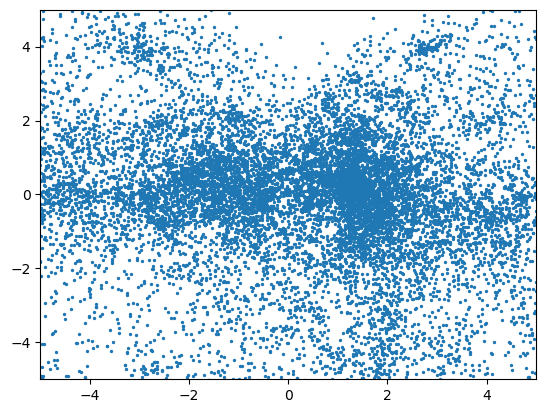

Mean r2= 0.310
Min r2= 0.050
Max r2= 0.710


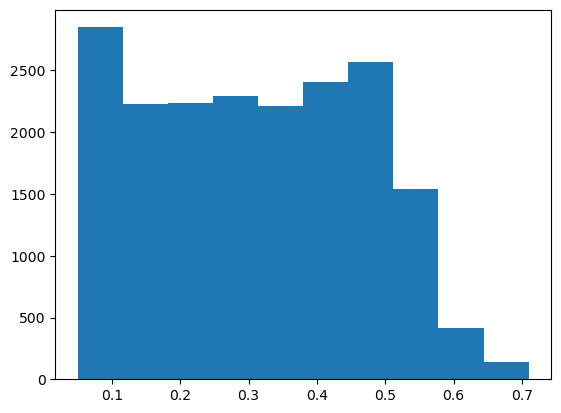

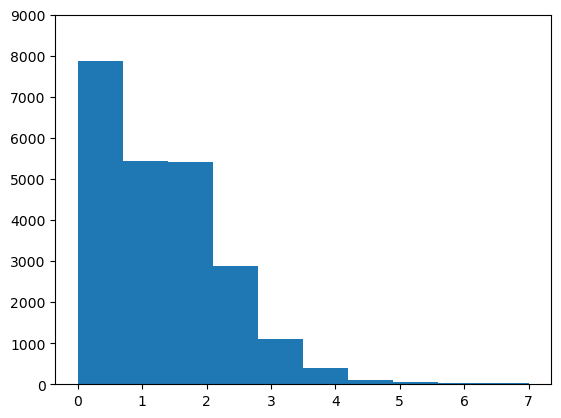

Best vx hrf_deriv= 1.948
Best vx size= 1.633
Best vx r2 no_hrf_grid= 0.706
Best vx r2 no_hrf_iter= 0.710
Best vx r2 iter= 0.710
Nvx = 18880 out of 23311, 81.0%


In [7]:
import matplotlib.pyplot as plt
gauss_fitter=pkl_data['model']
print(f'Min rsq = {np.nanmin(gauss_fitter.iterative_search_params[gauss_fitter.rsq_mask!=0,-1]):.3f}')
print(f'Mean rsq = {np.nanmean(gauss_fitter.iterative_search_params[gauss_fitter.rsq_mask>0,-1]):.3f}')
print(f'Max rsq = {gauss_fitter.iterative_search_params[:,-1].max():.3f}')
print(np.where(gauss_fitter.iterative_search_params[:,-1]==gauss_fitter.iterative_search_params[:,-1].max()))
best_vx=np.where(gauss_fitter.iterative_search_params[:,-1]==gauss_fitter.iterative_search_params[:,-1].max())

# Plot the location...
plt.scatter(gauss_fitter.iterative_search_params[:,0], gauss_fitter.iterative_search_params[:,1],marker='o', s=2)
plt.xlim(-5,5)
plt.ylim(-5,5)
plt.show()
print(f'Mean r2= {np.nanmean(gauss_fitter.iterative_search_params[gauss_fitter.rsq_mask!=0,7]):.3f}')
print(f'Min r2= {np.min(gauss_fitter.iterative_search_params[gauss_fitter.rsq_mask==1,7]):.3f}')
print(f'Max r2= {np.max(gauss_fitter.iterative_search_params[gauss_fitter.rsq_mask!=0,7]):.3f}')
plt.hist(gauss_fitter.iterative_search_params[gauss_fitter.rsq_mask!=0,7])
#plt.hist(gauss_fitter.iterative_search_params[:,7])
#plt.xlim(0,0.8)
#plt.ylim(0,9000)
plt.show()
plt.hist(gauss_fitter.iterative_search_params[:,2])
plt.ylim(0,9000)
plt.show()
print(f'Best vx hrf_deriv= {gauss_fitter.iterative_search_params[int(best_vx[0]),-3]:.3f}')
print(f'Best vx size= {gauss_fitter.iterative_search_params[int(best_vx[0]),2]:.3f}')
print(f'Best vx r2 no_hrf_grid= {gauss_fitter.gridsearch_params[int(best_vx[0]),-1]:.3f}')
print(f'Best vx r2 no_hrf_iter= {gauss_fitter.iterative_search_params[int(best_vx[0]),-1]:.3f}')
print(f'Best vx r2 iter= {gauss_fitter.iterative_search_params[int(best_vx[0]),-1]:.3f}')

# Rescue vxs where iterative fit was worse than grid fit
rsq_mask=np.ones(gauss_fitter.rsq_mask.shape) #this one is based on grid fit
rsq_mask[gauss_fitter.iterative_search_params[:,7]<r2_thr]=False
print(f'Nvx = {np.count_nonzero(gauss_fitter.rsq_mask)} out of {rsq_mask.shape[0]}, {np.count_nonzero(gauss_fitter.rsq_mask)/rsq_mask.shape[0]*100:.1f}%')

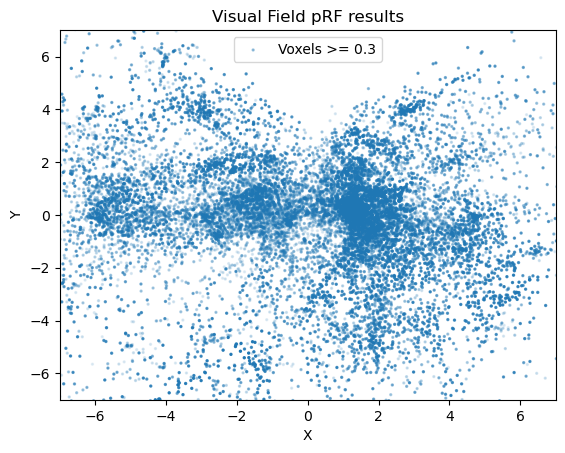

In [8]:
# Threshold the data
filtered_params = gauss_fitter.iterative_search_params[rsq_mask != 0]
# Weigth the data per their VE
r2_values = filtered_params[:, 7]
alpha = (r2_values - np.min(r2_values)) / (np.max(r2_values) - np.min(r2_values)) 
alpha = 0.1 + 0.9 * alpha
plt.scatter(filtered_params[:, 0], filtered_params[:, 1], s=2, marker='o', alpha=alpha,  label='Voxels >= 0.3')
plt.xlim(-7, 7)
plt.ylim(-7, 7)
plt.title('Visual Field pRF results')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

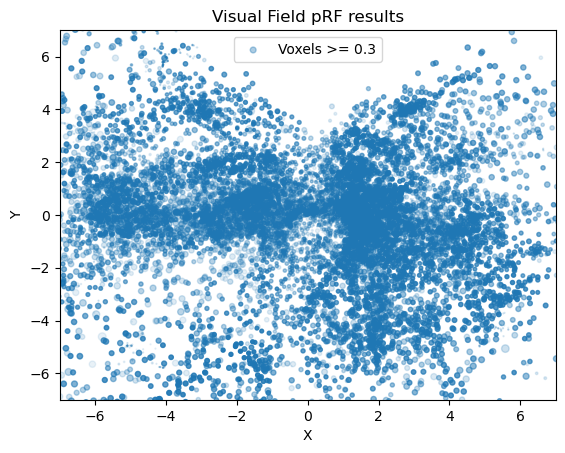

In [9]:
# Threshold the data
filtered_params = gauss_fitter.iterative_search_params[rsq_mask != 0]
# Weigth the data per their VE
prf_sizes = filtered_params[:, 2]
prf_sizes_scaled = 5 * prf_sizes 
r2_values = filtered_params[:, 7]
alpha = (r2_values - np.min(r2_values)) / (np.max(r2_values) - np.min(r2_values)) 
alpha = 0.1 + 0.9 * alpha
plt.scatter(filtered_params[:, 0], filtered_params[:, 1], s=prf_sizes_scaled, marker='o', alpha=alpha,  label='Voxels >= 0.3')
plt.xlim(-7, 7)
plt.ylim(-7, 7)
plt.title('Visual Field pRF results')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

In [10]:
### FOR THE PRESENTATION

# Filter receptive fields based on eccentricity
eccentricity = np.sqrt(filtered_params[:, 0]**2 + filtered_params[:, 1]**2)  # Eccentricity is the radial distance

# Define masks for each region
fovea_mask = eccentricity <= 2.5
parafovea_mask = (eccentricity > 2.5) & (eccentricity <= 4.2)
perifovea_mask = (eccentricity > 4.2) & (eccentricity <= 9.2)

# Get PRF sizes (sigma values) for each region
fovea_prf_sizes = prf_sizes[fovea_mask]
parafovea_prf_sizes = prf_sizes[parafovea_mask]
perifovea_prf_sizes = prf_sizes[perifovea_mask]

# Calculate average, standard deviation, and count for each region
fovea_avg = np.mean(fovea_prf_sizes)
fovea_std = np.std(fovea_prf_sizes)
fovea_count = fovea_mask.sum()  # Count of PRFs in fovea

parafovea_avg = np.mean(parafovea_prf_sizes)
parafovea_std = np.std(parafovea_prf_sizes)
parafovea_count = parafovea_mask.sum()  # Count of PRFs in parafovea

perifovea_avg = np.mean(perifovea_prf_sizes)
perifovea_std = np.std(perifovea_prf_sizes)
perifovea_count = perifovea_mask.sum()  # Count of PRFs in perifovea

# Print the results
print(f'Fovea (0-2.5°): Mean PRF size = {fovea_avg:.2f}, Std = {fovea_std:.2f}, Count = {fovea_count}')
print(f'Parafovea (2.5°-4.2°): Mean PRF size = {parafovea_avg:.2f}, Std = {parafovea_std:.2f}, Count = {parafovea_count}')
print(f'Perifovea (4.2°-7°): Mean PRF size = {perifovea_avg:.2f}, Std = {perifovea_std:.2f}, Count = {perifovea_count}')

Fovea (0-2.5°): Mean PRF size = 1.06, Std = 0.63, Count = 6538
Parafovea (2.5°-4.2°): Mean PRF size = 1.64, Std = 0.62, Count = 3287
Perifovea (4.2°-7°): Mean PRF size = 2.00, Std = 0.90, Count = 6186


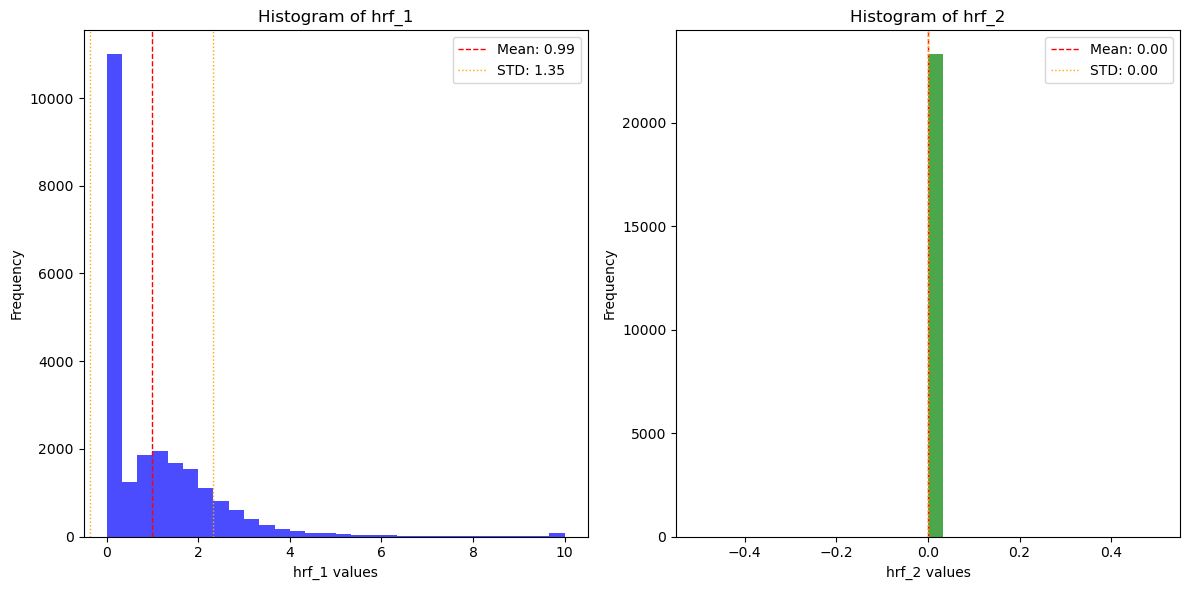

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming prf_params is already loaded and contains the required data
hrf_1 = prf_params[:, 5]
hrf_2 = prf_params[:, 6]

# Calculate mean and standard deviation for hrf_1 and hrf_2
mean_hrf_1 = np.mean(hrf_1)
std_hrf_1 = np.std(hrf_1)

mean_hrf_2 = np.mean(hrf_2)
std_hrf_2 = np.std(hrf_2)

# Create a figure for the histograms
plt.figure(figsize=(12, 6))

# Histogram for hrf_1
plt.subplot(1, 2, 1)
plt.hist(hrf_1, bins=30, color='blue', alpha=0.7)
plt.axvline(mean_hrf_1, color='red', linestyle='dashed', linewidth=1, label=f'Mean: {mean_hrf_1:.2f}')
plt.axvline(mean_hrf_1 - std_hrf_1, color='orange', linestyle='dotted', linewidth=1, label=f'STD: {std_hrf_1:.2f}')
plt.axvline(mean_hrf_1 + std_hrf_1, color='orange', linestyle='dotted', linewidth=1)
plt.title('Histogram of hrf_1')
plt.xlabel('hrf_1 values')
plt.ylabel('Frequency')
plt.legend()

# Histogram for hrf_2
plt.subplot(1, 2, 2)
plt.hist(hrf_2, bins=30, color='green', alpha=0.7)
plt.axvline(mean_hrf_2, color='red', linestyle='dashed', linewidth=1, label=f'Mean: {mean_hrf_2:.2f}')
plt.axvline(mean_hrf_2 - std_hrf_2, color='orange', linestyle='dotted', linewidth=1, label=f'STD: {std_hrf_2:.2f}')
plt.axvline(mean_hrf_2 + std_hrf_2, color='orange', linestyle='dotted', linewidth=1)
plt.title('Histogram of hrf_2')
plt.xlabel('hrf_2 values')
plt.ylabel('Frequency')
plt.legend()

# Adjust layout and show the plots
plt.tight_layout()
plt.show()